cl = ['r', 'g', 'b', 'c', 'm', 'y', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
t[[360.           1.05086957   1.74480626   4.        ]]
t[[400.           1.08412729   1.80857956   6.        ]]
t[[450.     1.24   1.57   8.  ]]
t[[490.           1.1282571    1.74498554  10.        ]]
t[[530.           1.17723814   1.68443586  12.        ]]
t[[570.           1.18964452   1.66433168  14.        ]]
t[[645.     0.84   2.27  16.  ]]
t[[650.           1.18526197   1.69636306  18.        ]]


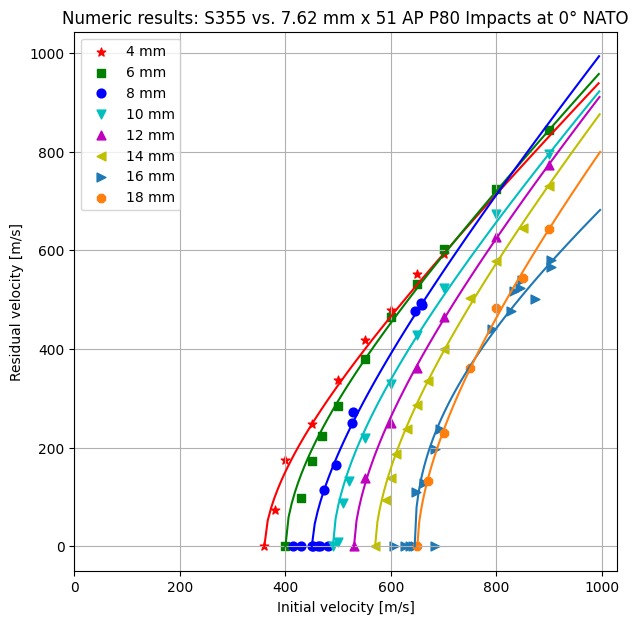

In [2]:
##############################
# Load and plot original data
# 2026-03-17_23-10-00 - tu są wyniki!!!
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import math
import pickle
import os
from datetime import datetime

from jupyter_server.utils import path2url
from pysr import PySRRegressor, TemplateExpressionSpec

#dane = np.genfromtxt('data/dane_2026-03-16.txt', delimiter=';', skip_header=1)
#wspolczynniki = np.genfromtxt('data/wspolczynniki_2026-03-16.txt', delimiter=';', skip_header=1)

#dane = np.genfromtxt('data/dane_2026-03-16.txt', delimiter=';', skip_header=1)
#wspolczynniki = np.genfromtxt('data/wspolczynniki_2026-03-16.txt', delimiter=';', skip_header=1)

dane = np.genfromtxt('data/dane_2026-03-17_exp_num.txt', delimiter=';', skip_header=1)
wspolczynniki = np.genfromtxt('data/wspolczynniki_2026-03-17_exp_num.txt', delimiter=';', skip_header=1)

def make_sequence(start_seq, end_seq, number_points):
    step = (end_seq - start_seq) / number_points
    vi_list = []
    a = 0
    actual_value = start_seq
    while a < number_points:
        actual_value = start_seq + a * step
        vi_list.append(actual_value)
        a = a + 1
    vi = np.array(vi_list)
    vi = np.sort(vi)
    return vi

def Vr(Vi, a, P, V_bl):
    res = np.zeros(Vi.shape[0])
    for id in range(Vi.shape[0]):
        p1 = math.pow(Vi[id], P) - math.pow(V_bl, P)
        if p1 > 0:
            p2 = a * math.pow(p1,1./P)
        else:
            p2 = 0
        res[id] = p2
    return res


plt.subplots(figsize=(7, 7))
#t = 18
color_list = ['r', 'g', 'b', 'c', 'm', 'y'] + list(mcolors.TABLEAU_COLORS.values())
markers = ["*", ",", "o", "v", "^", "<", ">", "8", "s", "p", "P", "h", "X", "D", "d"]
print('cl = ' + str(color_list))
id_color = 0
for t in range(4, 19, 2):
    wsp = wspolczynniki[wspolczynniki[:,3] == t]
    dd = dane[dane[:,2] == t]
    print('t' + str(wsp))
    #print(dd)
    vbl = wsp[0, 0]
    aa = wsp[0, 1]
    pp = wsp[0, 2]
    vi = make_sequence(vbl, 1000, 100)
    vir = Vr(vi, aa, pp, vbl)


    plt.scatter(dd[:,0], dd[:,1], c=color_list[id_color], label=str(t) + ' mm', marker=markers[id_color], s=40)
    #plt.plot(vi, vir, c=color_list[id_color], ls='-', label='RL,Vbl=%5.0f m/s, a=%5.2f, p=%5.1f' % tuple([vbl, aa,pp]))
    plt.plot(vi, vir, c=color_list[id_color], ls='-')
    id_color += 1
plt.xlabel('Initial velocity [m/s]')
plt.ylabel('Residual velocity [m/s]')
plt.title('Numeric results: S355 vs. 7.62 mm x 51 AP P80 Impacts at 0° NATO')
plt.xlim(xmin=0)
plt.legend()
plt.grid()

In [104]:
"""
###########################################3
# Symbolic regression for all thicknesses
data_l_X = []
data_l_y = []
for t in wspolczynniki[:,3].tolist():
    #dd = dane[dane[:,2] == t]
    wsp = wspolczynniki[wspolczynniki[:,3] == t]
    #print('t' + str(wsp))
    #print(dd)
    vbl = wsp[0, 0]
    aa = wsp[0, 1]
    pp = wsp[0, 2]
    vi = make_sequence(vbl, 1000, 100)
    vir = Vr(vi, aa, pp, vbl)
    XX_ = np.column_stack((vi, np.repeat(t,vi.shape[0])))
    data_l_X.append(XX_)
    data_l_y.append(vir)

XX_full = np.concatenate(data_l_X, axis=0)
y_full = np.concatenate(data_l_y, axis=0)
wspolczynniki_list = wspolczynniki[:,3].tolist()
"""

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import math
import matplotlib.colors as mcolors
from prompt_toolkit.shortcuts import confirm
from tqdm import tqdm

def calculate_pdf(min_val, max_val, step, my_function, frac = [1,1,1]):
    frac = np.asarray(frac)
    if np.sum(frac) < 0.0001:
        frac = np.asarray([1,1,1])
    frac = frac / np.sum(frac)

    border_left = 10 * step
    border_right = 10 * step
    grid_help = np.mgrid[min_val-border_left:max_val+border_right:step]
    x = grid_help
    y = my_function(grid_help)
    y_grad = np.abs(np.gradient(y))
    y_grad2 = np.abs(np.gradient(y_grad))

    x_ = x[10:-10]
    y_ = y[10:-10]
    y_grad_ = y_grad[10:-10]
    y_grad2_ = y_grad2[10:-10]

    y_pdf = np.zeros(y_grad2_.shape)
    y_pdf[0] = frac[0] * step + frac[1] * y_grad_[0] + frac[2] * y_grad2_[0]

    for i in range(1, y_pdf.shape[0]):
        val = frac[0] * step + frac[1] * y_grad_[i] + frac[2] * y_grad2_[i]
        y_pdf[i] = y_pdf[i-1] + val

    y_pdf_max = np.max(y_pdf)
    y_pdf /= y_pdf_max
    return (y_pdf, x_, y_, y_grad_, y_grad2_)

def plot_pdf(y_pdf, x_, y_, y_grad_, y_grad2_):
    plt.plot(x_, y_, color='r')
    plt.show()
    plt.plot(x_, y_grad_, color='b')
    plt.show()
    plt.plot(x_, y_grad2_, color='g')
    plt.show()
    plt.plot(x_, y_pdf, color='y')
    plt.show()

def sample_from_pdf(y_pdf, x_, y_, sample_size):
    r_n = np.random.rand(sample_size)
    rx = np.zeros(sample_size)
    ry = np.zeros(sample_size)
    for i in range(len(r_n)):
        a = 0
        while r_n[i] > y_pdf[a]:
            a += 1
        rx[i] = x_[a]
        ry[i] = y_[a]
    return rx, ry

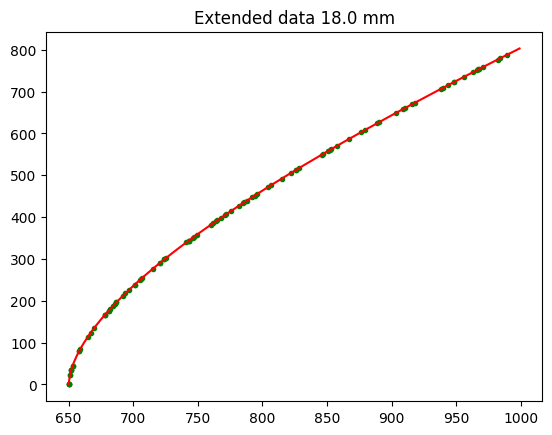

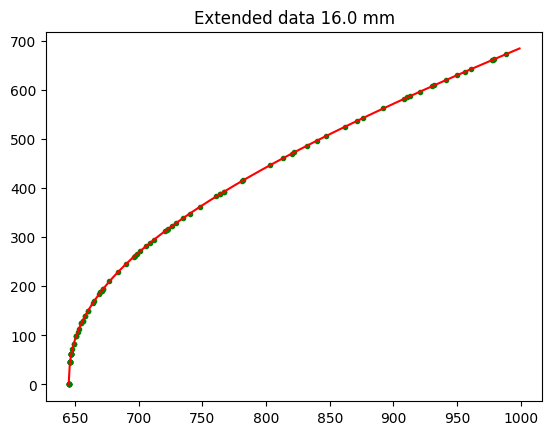

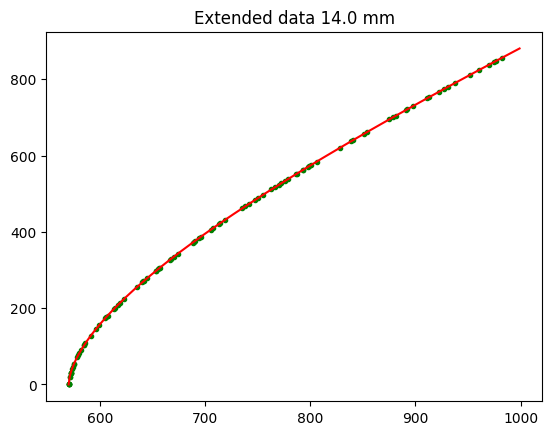

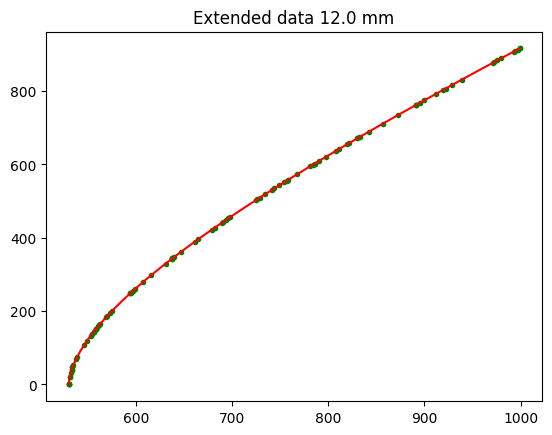

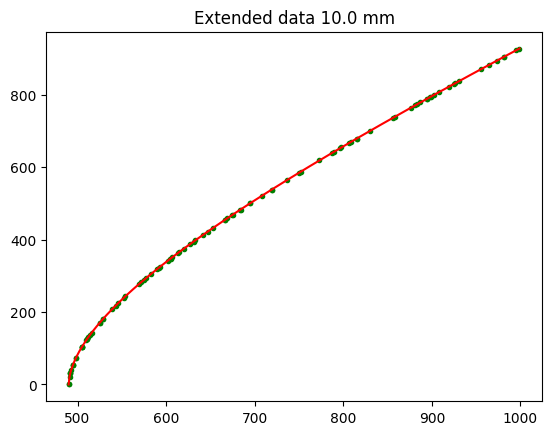

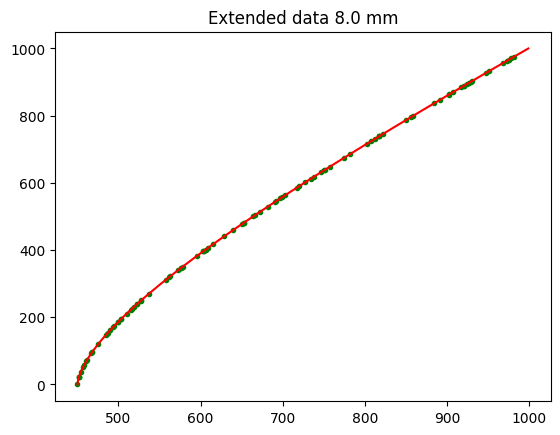

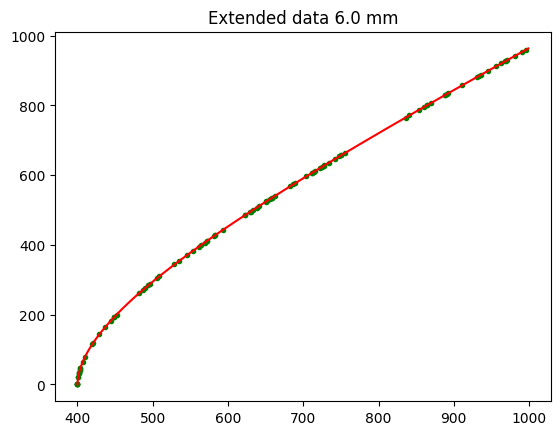

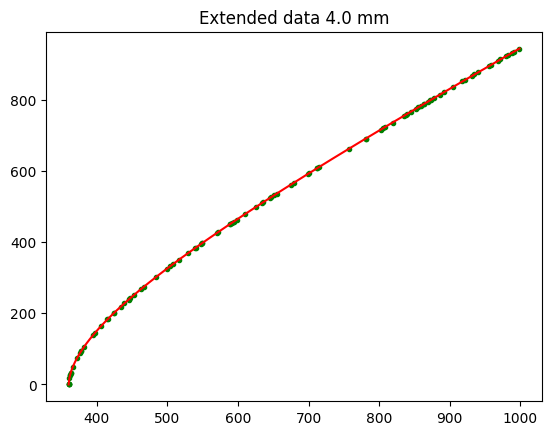

In [3]:
dane_extended = []
sample_size = 100
max_val = 1000
step = 1
frac = 0.99
frac = 0.5
#frac = [1, 0, 0]
#frac = [1, 1, 1]
#frac = [0, 0.01, 0.99]
#NOWE
#frac = [0, 0.5, 0.5]
#NOWE
frac = [0, 0.25, 0.75]
#frac = [0, 0, 1]

wspolczynniki_list = wspolczynniki[:,3].tolist()
full_data = []
for thickness in wspolczynniki_list:
    wsp = wspolczynniki[wspolczynniki[:,3] == thickness]
    vbl = wsp[0, 0]
    aa = wsp[0, 1]
    pp = wsp[0, 2]
    grid_help = np.mgrid[vbl-10:max_val:step]

    def function_helper(grid):
        y = Vr(grid, aa, pp, vbl)
        return y


    (y_pdf, x_, y_, y_grad_, y_grad2_) = calculate_pdf(vbl, 1000, 1, function_helper, frac)
    #plot_pdf(y_pdf, x_, y_, y_grad_, y_grad2_)
    rx, ry = sample_from_pdf(y_pdf, x_, y_, sample_size)

    #which_to_find_bool = np.abs(data_full[:,1] - thickness) < 0.0001
    #data_help = data_full[which_to_find_bool]


    plt.plot(x_, y_, color='r')
    plt.scatter(rx, ry, marker='.', color='g')
    #plt.scatter(data_help[:,0], data_help[:,2], marker='.', color='b')
    plt.title('Extended data ' + str(thickness) + " mm")
    plt.show()



    numeric_series = np.array([rx, np.repeat(thickness, sample_size), ry]).transpose()
    full_data.extend(numeric_series)
    #dane_extended = np.concatenate((dane_extended, numeric_series))


full_data_numpy = np.array(full_data)
#np.savetxt('full_data_numpy_025_075.csv', full_data_numpy)
XX_full = full_data_numpy[:,0:2]
y_full = full_data_numpy[:,2]


In [3]:
XX_full

NameError: name 'XX_full' is not defined

In [4]:
folder_name = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Utwórz katalog
os.makedirs("./results/" + folder_name, exist_ok=True)

print(f"Output directory: {folder_name}")


Output directory: 2026-03-17_23-10-00


In [5]:
def train_symbolic_regressor(XX_full_train, y_full_train):
    template = TemplateExpressionSpec(
        expressions=["p","a","vbl"],
        variable_names=["v", "t"],
        combine="(v^p(t) - vbl(t)^p(t))^(1/p(t))*a(t)",
    )

    model = PySRRegressor(
        expression_spec = template,
        maxsize=20,
        populations=100,
        population_size=100,
        precision=64,
        #constraints={'^': (-1, 1)},
        constraints={'^': (-1, 3)},
        niterations=20,  # < Increase me for better results
        binary_operators=["+", "*", "^","/"],
        unary_operators=["square", "log", "cube", "log10", "log2", "sqrt", "log1p", "inv"],
        elementwise_loss="loss(prediction, target) = (prediction - target)^2",
        early_stop_condition=(
            "stop_if(loss, complexity) = loss < 1.8e+02 && complexity <= 12"
            # Stop early if we find a good and simple equation
        ),
        # ^ Custom loss function (julia syntax),
    )
    model.fit(XX_full_train, y_full_train)
    return model


In [6]:
for t in wspolczynniki_list:
    print("Thickness: " + str(t) + " mm")
    XX_full_train_ids = XX_full[:, 1] != t
    XX_full_test_ids = XX_full[:, 1] == t

    XX_full_train = XX_full[XX_full_train_ids]
    XX_full_test = XX_full[XX_full_test_ids]
    y_full_train = y_full[XX_full_train_ids]
    y_full_test = y_full[XX_full_test_ids]

    out_model = train_symbolic_regressor(XX_full_train, y_full_train)
    path_help = './results/' + folder_name + '/sr_model_t=' + str(t) + '.pkl'
    with open(path_help, 'wb') as file:
        pickle.dump(out_model, file)


D:\Projects\Python\PycharmProjects\WebScrapper\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...


Thickness: 18.0 mm


[ Info: Started!



Expressions evaluated per second: 3.540e+02
Progress: 1 / 2000 total iterations (0.050%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
9           3.297e+04  0.000e+00  ╭ p = inv(log1p(#1))
                                  ├ a = inv(log1p(log1p(#1)))
                                  ╰ vbl = cube(1.9707)
10          2.833e+04  1.514e-01  ╭ p = inv(log(#1))
                                  ├ a = 0.87226
                                  ╰ vbl = square(log1p(log1p(#1 + #1)))
12          2.629e+04  3.736e-02  ╭ p = inv(log(#1))
                                  ├ a = 0.87226
                                  ╰ vbl = square(log1p(log1p(#1)) * sqrt(log1p(#1)))
14          2.568e+04  1.177e-02  ╭ p = inv(log(#1))
                                  ├ a = 0.94943
                                  

[ Info: Final population:
[ Info: Results saved to:


...

───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
3           1.610e+04  0.000e+00  ╭ p = 0.38139
                                  ├ a = 8.4499
                                  ╰ vbl = 228.37
4           1.320e+04  1.991e-01  ╭ p = 0.10891
                                  ├ a = 712.83
                                  ╰ vbl = log1p(#1)
5           5.303e+03  9.117e-01  ╭ p = 0.35807
                                  ├ a = #1
                                  ╰ vbl = #1 * 18.782
6           3.721e+03  3.543e-01  ╭ p = 1.3911
                                  ├ a = 1.2727
                                  ╰ vbl = log1p(#1) * 204.35
7           1.614e+03  8.352e-01  ╭ p = 1.5869
                                  ├ a = 1.1839
                                  ╰ vbl = (#1 + 13.389) / 0.048308
9           1.484e+03  4.182e-02  ╭ p = 1.4716
                                  ├ a = #1 ^ 0.098622
    

[ Info: Started!



Expressions evaluated per second: 2.140e+02
Progress: 1 / 2000 total iterations (0.050%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
12          3.382e+04  0.000e+00  ╭ p = inv(sqrt(log1p(#1)))
                                  ├ a = sqrt(inv(log1p(#1)))
                                  ╰ vbl = sqrt(inv(log1p(#1)))
15          3.190e+04  1.947e-02  ╭ p = (sqrt(#1) * 2.2375) / #1
                                  ├ a = (sqrt(#1) * 2.2375) / #1
                                  ╰ vbl = #1 / #1
17          3.168e+04  3.557e-03  ╭ p = sqrt(#1) * (2.2375 / #1)
                                  ├ a = (sqrt(#1) * 2.2375) / #1
                                  ╰ vbl = (#1 + #1) / #1
18          3.155e+04  3.830e-03  ╭ p = (sqrt(#1) * 2.2375) / #1
                                  ├ a = (sqrt(#1)

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
  - outputs\20260317_234320_7cI5Uc\hall_of_fame.csv


In [7]:
#out_model.equations_.to_csv("xxx.csv", index=False, encoding="utf-8", sep="\t")
dir_help = './results/' + folder_name + '/'
all_files = os.listdir(dir_help)
for file_name in all_files:
    full_path = os.path.join(dir_help, file_name)
    if os.path.isfile(full_path) and file_name.lower().endswith(".pkl"):
        print(full_path)
        with open(full_path, 'rb') as file:
            # Load the pickled data
            loaded_model = pickle.load(file)
            loaded_model.equations_.to_csv(dir_help + file_name + ".csv", index=False, encoding="utf-8", sep="\t")

./results/2026-03-17_23-10-00/sr_model_t=10.0.pkl
./results/2026-03-17_23-10-00/sr_model_t=12.0.pkl
./results/2026-03-17_23-10-00/sr_model_t=14.0.pkl
./results/2026-03-17_23-10-00/sr_model_t=16.0.pkl
./results/2026-03-17_23-10-00/sr_model_t=18.0.pkl
./results/2026-03-17_23-10-00/sr_model_t=4.0.pkl
./results/2026-03-17_23-10-00/sr_model_t=6.0.pkl
./results/2026-03-17_23-10-00/sr_model_t=8.0.pkl


In [4]:
full_data_numpy = np.loadtxt('full_data_numpy_025_075.csv')
#full_data_numpy = np.array(full_data)
#np.savetxt('full_data_numpy_025_075.csv', full_data_numpy)
XX_full = full_data_numpy[:,0:2]
y_full = full_data_numpy[:,2]

In [5]:
# for unfirom distribution
def get_params_for_thickness(t):
    p = 1
    a = 1
    vbl = 1
    if t == 4:
        p = lambda x: (-1.5507760900115786 / x) + 1.7684375679231885
        a = lambda x : 1.178036908261981
        vbl = lambda x : (x * 21.11285465317287) + 269.96723313976764
    if t == 6:
        p = lambda x: 1.6082325699904603
        a = lambda x : math.pow(1, 0.0736795568697973)
        vbl = lambda x : (x * 20.699050689985967) + 277.1963476344057
    if t == 8:
        p = lambda x: math.pow(x, 0.14515048595684368) + 0.1558834893281958
        a = lambda x : 1.1958015250694984
        vbl = lambda x : (x * 21.982450727028972) + 254
    if t == 10:
        p = lambda x: 1.5580116935676922
        a = lambda x : math.log10((x * 0.48907085872105316) + 11.03366949942125)
        vbl = lambda x : (x + 12.495122101150363) * 21.306336323728694
    if t == 12:
        p = lambda x: math.pow(x, 0.16725005580779143)
        a = lambda x : 1.2326235450489995
        vbl = lambda x : (x + 10.095456012973099) * 23.135099810554383
    if t == 14:
        p = lambda x: math.sqrt(math.log10(x) + 1.676846614447631)
        a = lambda x : 1.158683389792202
        vbl = lambda x : math.pow((x + 29.455497228507785), 1.676846614447631)
    if t == 16:
        p = lambda x: 1.538292534665321
        a = lambda x : math.pow(1.1730428578939813, math.log10(x))
        vbl = lambda x : (x / 0.044087339435773004) + 238.36083914732652
    if t == 18:
        p = lambda x: math.log10(math.log(x)) + 1.2983245945625426
        a = lambda x : 1.1510833668425169
        vbl = lambda x : (x * 21.58567170444433) + 264.6279901178961

    return (p, a, vbl)

def vr_(v, t, p, a, vbl):
    part1 = math.pow(v,p(t)) - math.pow(vbl(t),p(t))
    if part1 > 0:
        return math.pow(part1, 1/p(t)) * a(t)
    else:
        return 0



In [33]:
# distribution 0 0.01 0.99

def cube(x):
    return math.pow(x, 3)

def square(x):
    return math.pow(x, 2)

def get_params_for_thickness(t):
    p = 1
    a = 1
    vbl = 1
    if t == 4:
        # p = 1.2707477732405137; a = log10(#1 + 20.42465892007432); vbl = cube(log(cube((#1 + 11.831756788810187) ^ 0.8499695671418912)))
        p = lambda x: 1.2707477732405137
        a = lambda x : math.log10(x + 20.42465892007432)
        vbl = lambda x : cube(math.log(cube(math.pow((x + 11.831756788810187), 0.8499695671418912))))
    if t == 6:
        # p = 1.0935564682932424; a = sqrt(log2(#1)); vbl = sqrt((#1 + 1.0939508245543033) / 4.679271662193321e-5)
        p = lambda x: 1.0935564682932424
        a = lambda x : math.sqrt(math.log2(x))
        vbl = lambda x : math.sqrt((x + 1.0939508245543033) / 4.679271662193321e-5)
    if t == 8:
        #1.321752275957436; a = #1 ^ 0.1469269911008023; vbl = (#1 * 20.977429777694137) + 272.40478201054714
        p = lambda x: 1.321752275957436
        a = lambda x : math.pow(x, 0.1469269911008023)
        vbl = lambda x : (x * 20.977429777694137) + 272.40478201054714
    if t == 10:
        #p = 1.2202059191036054; a = sqrt(log1p(#1)); vbl = (#1 / 0.046842088997013684) + 265.70781273118354
        p = lambda x: 1.2202059191036054
        a = lambda x : math.sqrt(math.log1p(x))
        vbl = lambda x : (x / 0.046842088997013684) + 265.70781273118354
    if t == 12:
        #p = 1.2254101470077692; a = sqrt(log1p(#1)); vbl = (#1 * 20.915526253720472) + 273.5197812841737
        p = lambda x: 1.2254101470077692
        a = lambda x : math.sqrt(math.log1p(x))
        vbl = lambda x : (x * 20.915526253720472) + 273.5197812841737
    if t == 14:
        # p = 1.2239656813337807; a = sqrt(log1p(#1)); vbl = log1p(#1 + 21.676135257292184) ^ 4.9447917278733255
        p = lambda x: 1.2239656813337807
        a = lambda x : math.sqrt(math.log1p(x))
        vbl = lambda x : math.pow(math.log1p(x + 21.676135257292184), 4.9447917278733255)
    if t == 16:
        #p = #1 ^ 0.15169802304145838; a = 1.3293305085689204; vbl = (#1 * 20.833456304449992) + 274.9964993134428
        p = lambda x: math.pow(x, 0.15169802304145838)
        a = lambda x : 1.3293305085689204
        vbl = lambda x : (x * 20.833456304449992) + 274.9964993134428
    if t == 18:
        # p = 1.0965065054155894; a = sqrt(sqrt(#1)); vbl = (#1 * 23.293862292157517) + 243.88585017220512
        p = lambda x: 1.0965065054155894
        a = lambda x : math.sqrt(math.sqrt(x))
        vbl = lambda x : (x * 23.293862292157517) + 243.88585017220512

    return (p, a, vbl)

def vr_(v, t, p, a, vbl):
    part1 = math.pow(v,p(t)) - math.pow(vbl(t),p(t))
    if part1 > 0:
        return math.pow(part1, 1/p(t)) * a(t)
    else:
        return 0



In [6]:
# distribution 0, 0.25, 0.75

def cube(x):
    return math.pow(x, 3)

def square(x):
    return math.pow(x, 2)

def get_params_for_thickness(t):
    p = 1
    a = 1
    vbl = 1
    if t == 4:
        # p = 1.5605645868498481; a = 1.198838040976907; vbl = (#1 * 20.83977045019187) + 274.8828696056518
        p = lambda x: 1.5605645868498481
        a = lambda x : 1.198838040976907
        vbl = lambda x : (x * 20.83977045019187) + 274.8828696056518
    if t == 6:
        # p = 1.4716183740781843; a = #1 ^ 0.09862155442612726; vbl = (#1 + 12.957462978465221) / 0.04762822572258125
        p = lambda x: 1.4716183740781843
        a = lambda x : math.pow(x, 0.09862155442612726)
        vbl = lambda x : (x + 12.957462978465221) / 0.04762822572258125
    if t == 8:
        # p = 1.5337089448595322; a = #1 ^ 0.07982204182064179; vbl = (#1 + 12.696981118708871) * 21.17466689316614
        p = lambda x: 1.5337089448595322
        a = lambda x : math.pow(x, 0.07982204182064179)
        vbl = lambda x : (x + 12.696981118708871) * 21.17466689316614
    if t == 10:
        # p = 1.4940632035957044; a = #1 ^ 0.09139616752493382; vbl = (#1 / 0.04666991664171184) + 264.29945874980416
        p = lambda x: 1.4940632035957044
        a = lambda x : math.pow(x, 0.09139616752493382)
        vbl = lambda x : (x / 0.04666991664171184) + 264.29945874980416
    if t == 12:
        # p = 1.5897076420665368; a = 1.1660489616315415; vbl = (#1 * 20.829716280157456) + 275.0200476635551
        p = lambda x: 1.5897076420665368
        a = lambda x : 1.1660489616315415
        vbl = lambda x : (x * 20.829716280157456) + 275.0200476635551
    if t == 14:
        # p = (#1 + -1.8794599788193975) * (1.5409724184687126 / (#1 + -1.6629993594920005)); a = 1.2259290538825467; vbl = (#1 + 12.808488439502135) * 21.096397567852364
        p = lambda x: (x + -1.8794599788193975) * (1.5409724184687126 / (x + -1.6629993594920005))
        a = lambda x : 1.2259290538825467
        vbl = lambda x : (x + 12.808488439502135) * 21.096397567852364
    if t == 16:
        # p = 1.6008791747417752; a = #1 ^ 0.07831768870647768; vbl = (#1 * 20.834204424441975) + 274.9678693890422
        p = lambda x: 1.6008791747417752
        a = lambda x : math.pow(x, 0.07831768870647768)
        vbl = lambda x : (x * 20.834204424441975) + 274.9678693890422
    if t == 18:
        # p = 1.4600388763283796; a = 1.252629287938389 ^ log10(#1); vbl = square(#1 + 1.5092063759037806) + 329.46359117116464
        p = lambda x: 1.4600388763283796
        a = lambda x : math.pow(1.252629287938389, math.log10(x))
        vbl = lambda x : square(x + 1.5092063759037806) + 329.46359117116464

    return (p, a, vbl)

def vr_(v, t, p, a, vbl):
    part1 = math.pow(v,p(t)) - math.pow(vbl(t),p(t))
    if part1 > 0:
        return math.pow(part1, 1/p(t)) * a(t)
    else:
        return 0


In [7]:
(p, a, vbl) = get_params_for_thickness(4)
vbl(4)

358.2419514064193

t[[650.           1.18526197   1.69636306  18.        ]]
t[[645.     0.84   2.27  16.  ]]
t[[570.           1.18964452   1.66433168  14.        ]]
t[[530.           1.17723814   1.68443586  12.        ]]
t[[490.           1.1282571    1.74498554  10.        ]]
t[[450.     1.24   1.57   8.  ]]
t[[400.           1.08412729   1.80857956   6.        ]]
t[[360.           1.05086957   1.74480626   4.        ]]


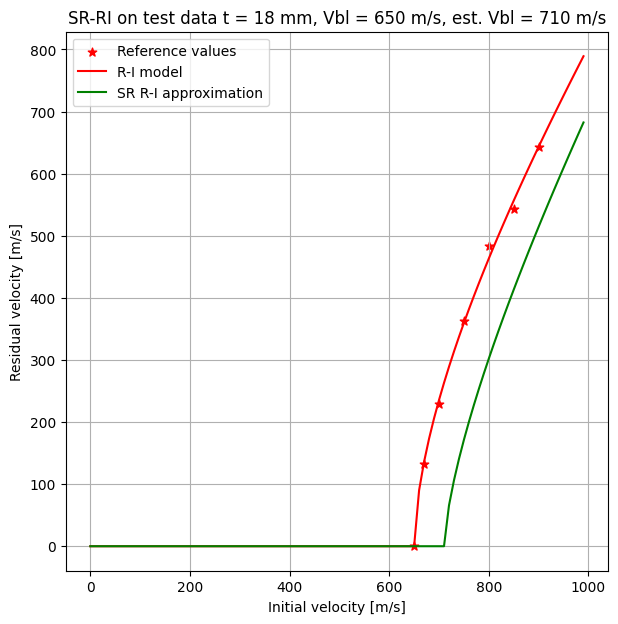

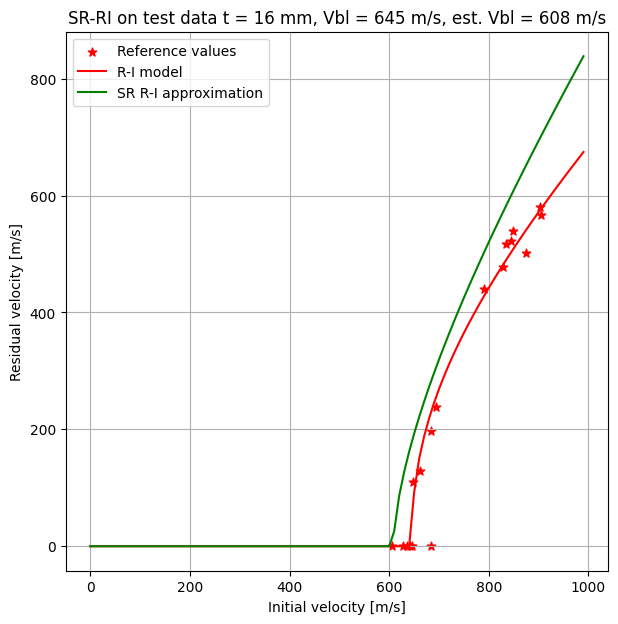

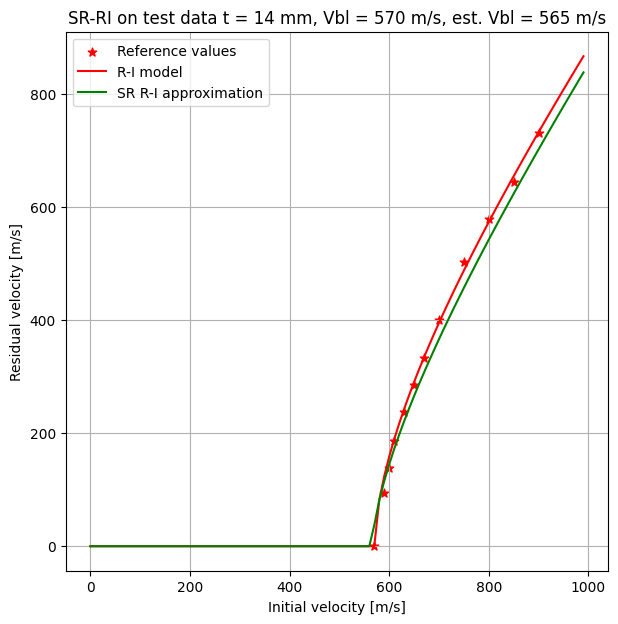

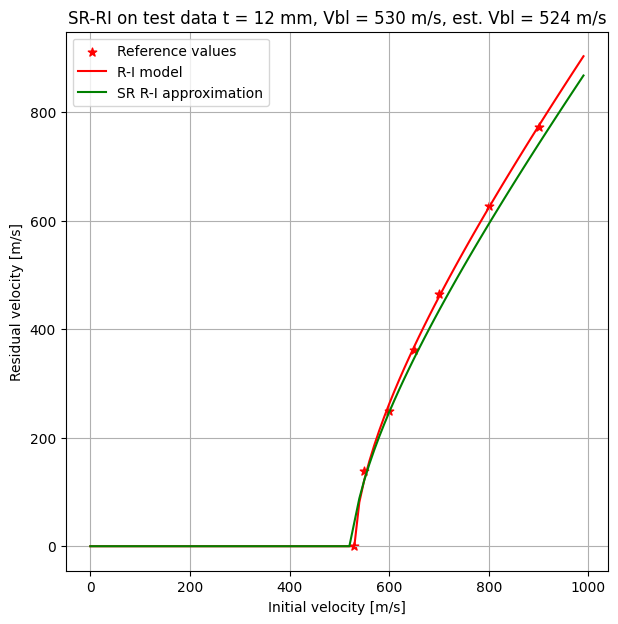

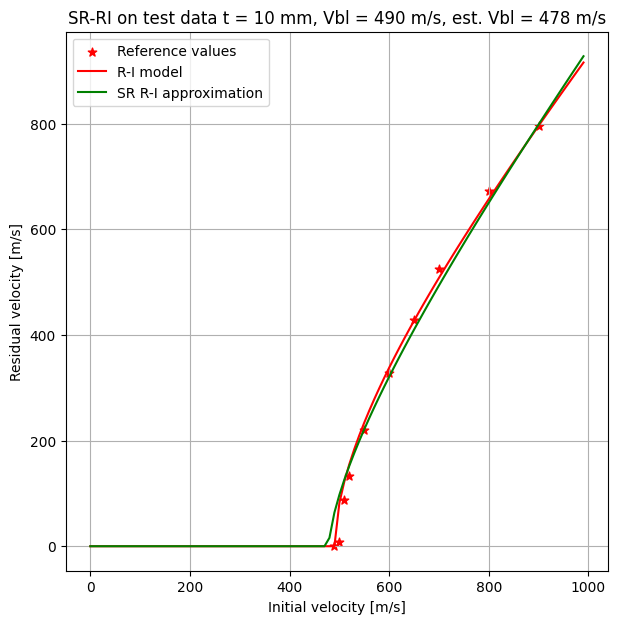

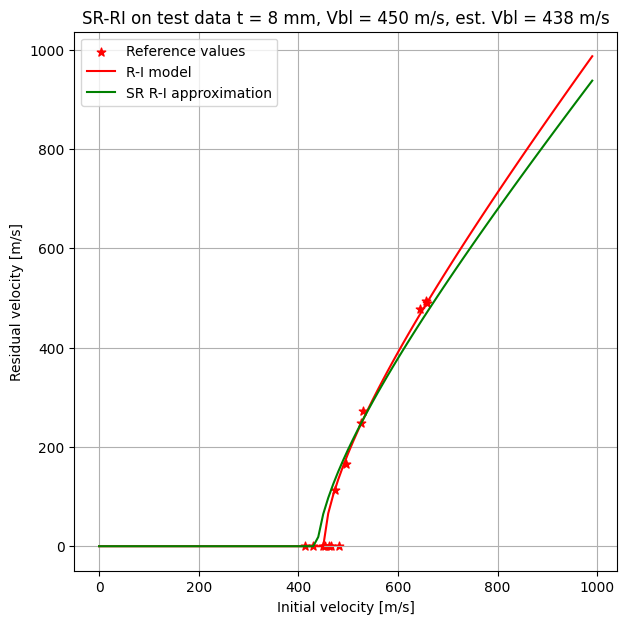

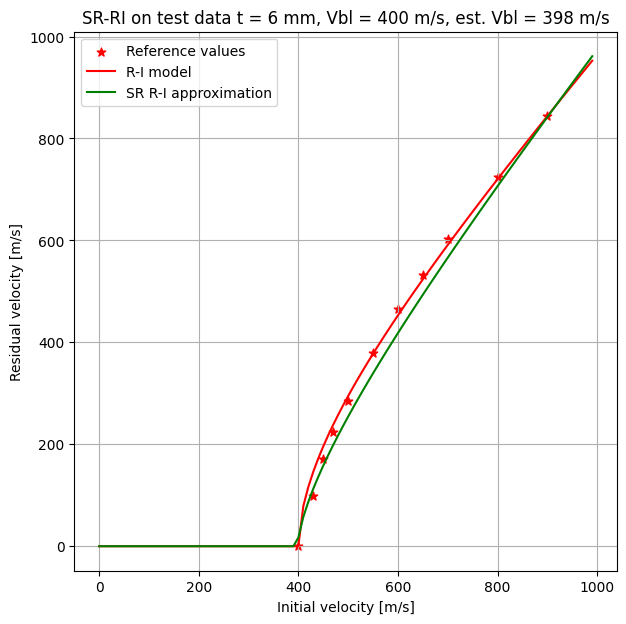

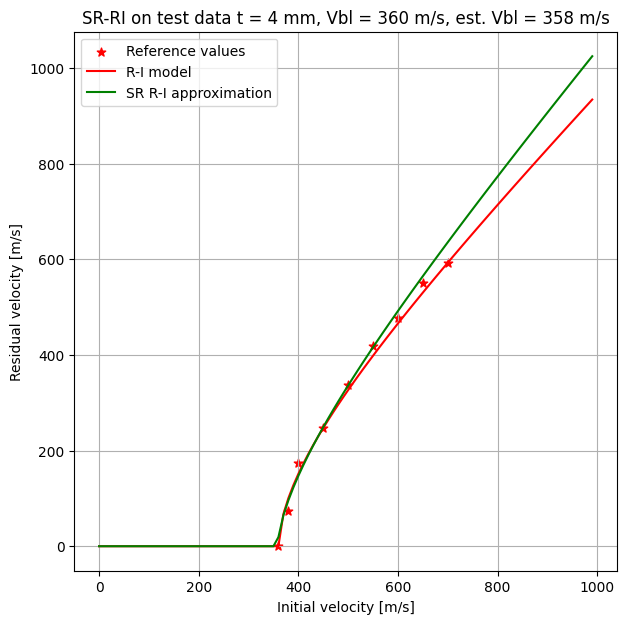

In [7]:
list_vr = []
list_vr_est = []
list_vbl = []
list_vbl_est = []
wspolczynniki_list = wspolczynniki[:,3].tolist()
for t in wspolczynniki_list:
    fig, ax = plt.subplots(figsize=(7, 7))
    (p, a, vbl) = get_params_for_thickness(t)

    id_color = 0
    wsp = wspolczynniki[wspolczynniki[:,3] == t]
    dd = dane[dane[:,2] == t]
    print('t' + str(wsp))
    #print(dd)
    vbl_ = wsp[0, 0]
    aa_ = wsp[0, 1]
    pp_ = wsp[0, 2]
    vi_ = make_sequence(0, 1000, 100)
    vir_ = Vr(vi_, aa_, pp_, vbl_)


    ax.scatter(dd[:,0], dd[:,1], c=color_list[id_color], label='Reference values', marker=markers[id_color], s=40)
    #plt.plot(vi, vir, c=color_list[id_color], ls='-', label='RL,Vbl=%5.0f m/s, a=%5.2f, p=%5.1f' % tuple([vbl, aa,pp]))
    ax.plot(vi_, vir_, c=color_list[id_color], ls='-', label='R-I model')

    vr_list = []
    for id_t in range(vi_.shape[0]):
        vr_list.append(vr_(vi_[id_t], t, p, a, vbl))

    list_vr.append(vir_)
    list_vr_est.append(np.array(vr_list))
    list_vbl.append(vbl_)
    list_vbl_est.append(vbl(t))

    plt.title("SR-RI on test data t = " + str(int(t)) + " mm" + ", Vbl = " + str(int(vbl_)) + " m/s, est. Vbl = " + str(int(vbl(t))) + " m/s")
    ax.plot(vi_, vr_list, c=color_list[id_color + 1], ls='-', label='SR R-I approximation')

    plt.xlabel('Initial velocity [m/s]')
    plt.ylabel('Residual velocity [m/s]')

    ax.legend()
    plt.grid()
    #plt.savefig("./figures/test_sr_ri_" + str(round(t,)) + ".eps", dpi=300, format='eps', bbox_inches="tight")

t[[650.           1.18526197   1.69636306  18.        ]]
t[[645.     0.84   2.27  16.  ]]
t[[570.           1.18964452   1.66433168  14.        ]]
t[[530.           1.17723814   1.68443586  12.        ]]
t[[490.           1.1282571    1.74498554  10.        ]]
t[[450.     1.24   1.57   8.  ]]
t[[400.           1.08412729   1.80857956   6.        ]]
t[[360.           1.05086957   1.74480626   4.        ]]


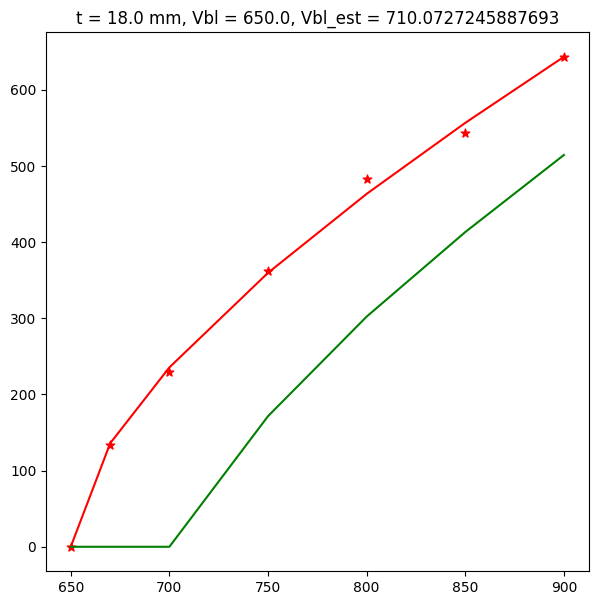

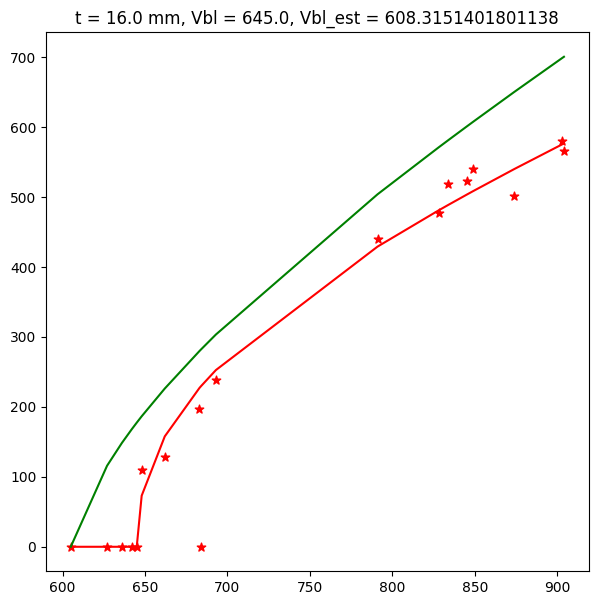

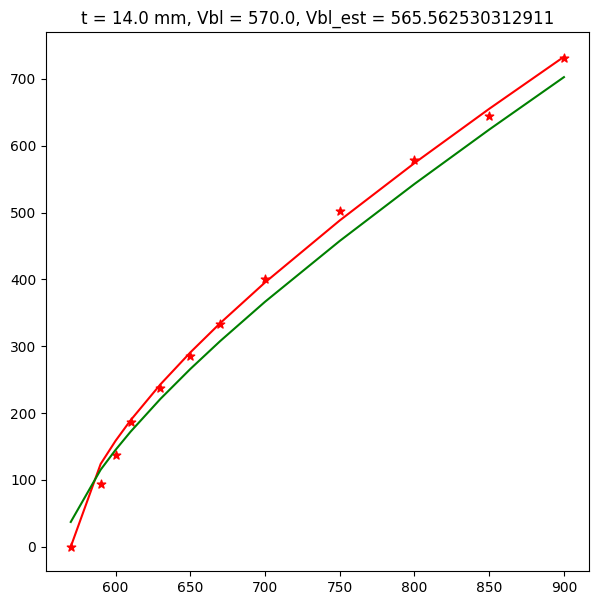

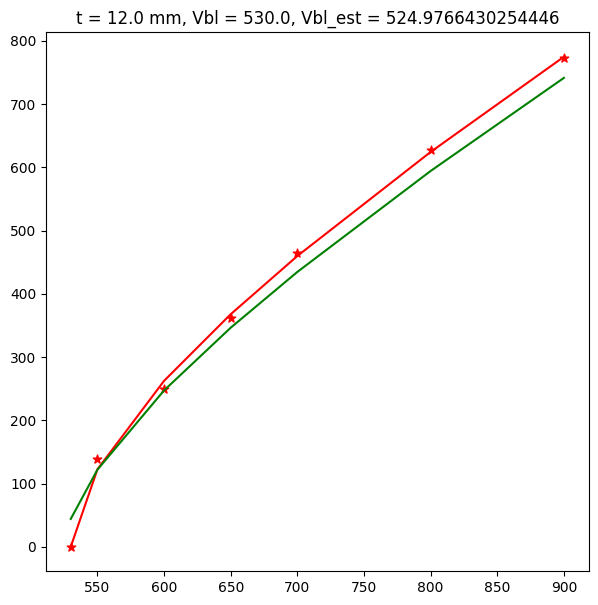

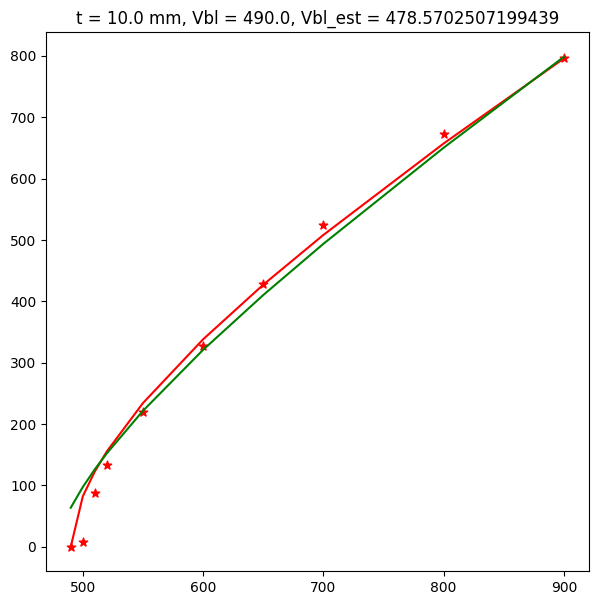

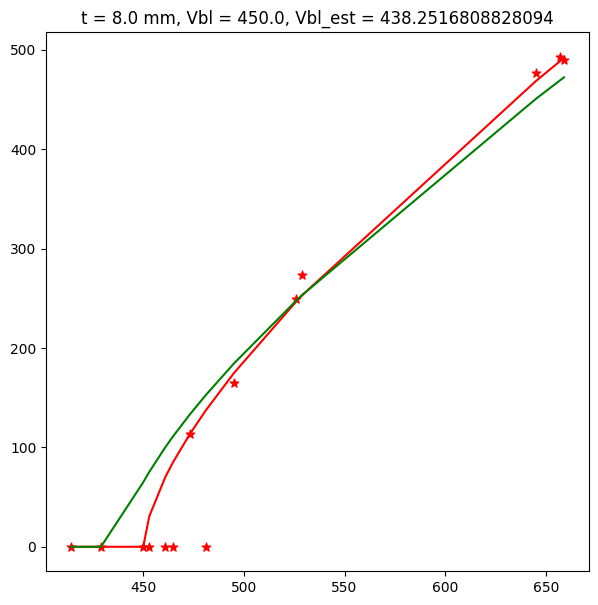

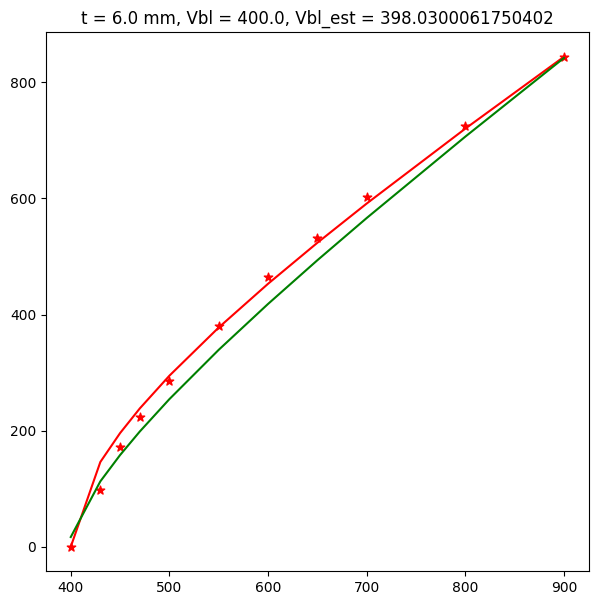

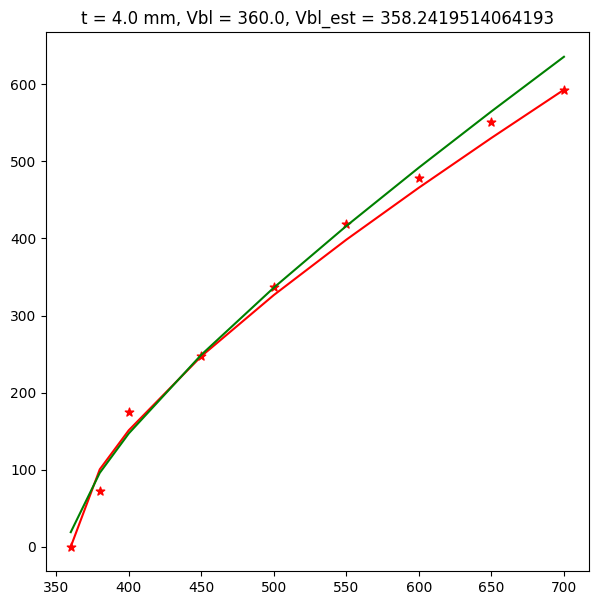

In [8]:
list_vr = []
list_vr_est = []
list_vbl = []
list_vbl_est = []

for t in wspolczynniki_list:
    plt.subplots(figsize=(7, 7))
    (p, a, vbl) = get_params_for_thickness(t)

    id_color = 0
    wsp = wspolczynniki[wspolczynniki[:,3] == t]
    dd = dane[dane[:,2] == t]
    print('t' + str(wsp))
    #print(dd)
    vbl_ = wsp[0, 0]
    aa_ = wsp[0, 1]
    pp_ = wsp[0, 2]
    #vi_ = make_sequence(0, 1000, 100)
    vi_ = dd[:,0]
    vir_ = Vr(vi_, aa_, pp_, vbl_)


    plt.scatter(dd[:,0], dd[:,1], c=color_list[id_color], label=str(t) + ' mm', marker=markers[id_color], s=40)
    #plt.plot(vi, vir, c=color_list[id_color], ls='-', label='RL,Vbl=%5.0f m/s, a=%5.2f, p=%5.1f' % tuple([vbl, aa,pp]))
    plt.plot(vi_, vir_, c=color_list[id_color], ls='-')

    vr_list = []
    for id_t in range(vi_.shape[0]):
        vr_list.append(vr_(vi_[id_t], t, p, a, vbl))

    list_vr.append(vir_)
    list_vr_est.append(np.array(vr_list))
    list_vbl.append(vbl_)
    list_vbl_est.append(vbl(t))

    plt.title("t = " + str(t) + " mm" + ", Vbl = " + str(vbl_) + ", Vbl_est = " + str(vbl(t)))
    plt.plot(vi_, vr_list, c=color_list[id_color + 1], ls='-')
    #plt.savefig("./figures/test" + str(round(t,)) + ".eps", dpi=300, format='eps', bbox_inches="tight")

In [11]:
wspolczynniki_list

[18.0, 16.0, 14.0, 12.0, 10.0, 8.0, 6.0, 4.0]

In [10]:
t = 8
dd = dane[dane[:,2] == t]
dd[:,0]

array([659., 657., 645., 529., 526., 495., 481., 473., 465., 461., 453.,
       450., 429., 414.])

"\nif save_flile is not None:\n        plt.savefig(save_flile, format='eps')\nplt.show()\n"

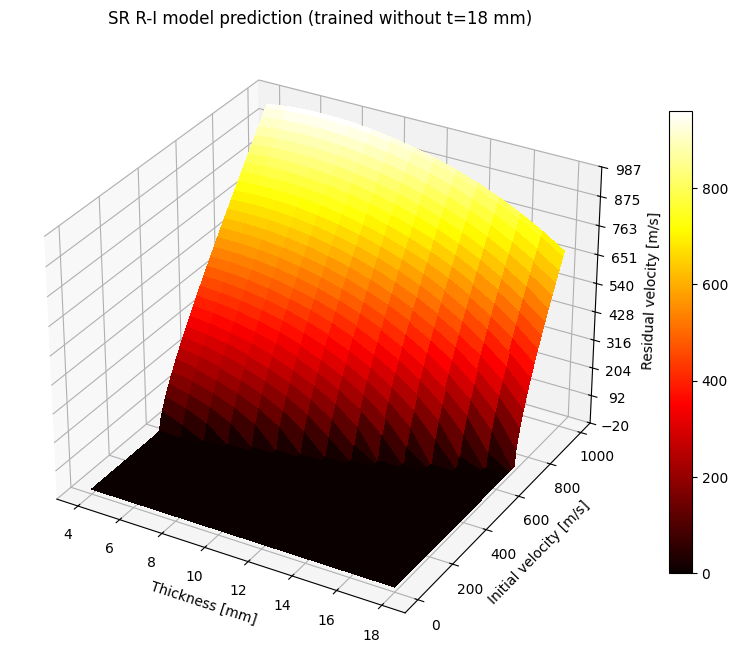

In [11]:
##############################
# Visualization 3d
from matplotlib.ticker import LinearLocator
tt = 18
(p, a, vbl) = get_params_for_thickness(tt)
#(v^p(t) - vbl(t)^p(t))^(1/p(t))*a(t)
def vr_(v, t, p, a, vbl):
    part1 = math.pow(v,p(t)) - math.pow(vbl(t),p(t))
    if part1 > 0:
        return math.pow(part1, 1/p(t)) * a(t)
    else:
        return 0
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 10))
ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.0f}')
plt.title('SR R-I model prediction (trained without t=' + str(tt) + ' mm)')
# Add a color bar which maps values to colors.

v_help = np.arange(0, 1000, 10)
t_help = np.arange(4, 19, 1)
v_help, t_help = np.meshgrid(v_help, t_help)
z = np.zeros(v_help.shape)
for x_id in range(z.shape[0]):
    for y_id in range(z.shape[1]):
        z[x_id, y_id] = vr_(v_help[x_id, y_id],
                                           t_help[x_id, y_id], p, a, vbl)

ax.set(xlabel=('Thickness [mm]'), ylabel=('Initial velocity [m/s]'), zlabel=('Residual velocity [m/s]'))
# viridis, inferno
surf = ax.plot_surface(t_help, v_help, z, cmap='hot', linewidth=0, antialiased=False)
#ax.view_init(0, 10)
fig.colorbar(surf, shrink=0.6, location='right')
#plt.savefig("./figures/symbsurf.eps", format='eps', bbox_inches='tight')
#plt.savefig("./figures/sr_ri_surf" + str((int(tt))) + ".eps", format='eps', bbox_inches='tight')
"""
if save_flile is not None:
        plt.savefig(save_flile, format='eps')
plt.show()
"""

In [9]:
def rmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred))

def r2_score(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    ss_res = np.sum((y_true - y_pred) ** 2)            # suma kwadratów reszt
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)   # całkowita wariancja

    return 1 - ss_res / ss_tot

def relative_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    eps = 1e-12
    return np.abs(y_true - y_pred) / (np.abs(y_true) + eps)



In [10]:

rmse_list = []
mae_list = []
r2_list = []
id_list = 0

eps = 0.000001

for id_list in range(len(list_vr)):
    id_arr = 0
    while list_vr[id_list][id_arr] < eps and list_vr_est[id_list][id_arr] < eps and id_arr < list_vr[id_list].shape[0]:
            id_arr += 1

    rmse_list.append(rmse(list_vr[id_list][id_arr:list_vr[id_list].shape[0]], list_vr_est[id_list][id_arr:list_vr[id_list].shape[0]]))
    mae_list.append(mae(list_vr[id_list][id_arr:list_vr[id_list].shape[0]], list_vr_est[id_list][id_arr:list_vr[id_list].shape[0]]))
    r2_list.append(r2_score(list_vr[id_list][id_arr:list_vr[id_list].shape[0]], list_vr_est[id_list][id_arr:list_vr[id_list].shape[0]]))

print("RMSE = " + str(np.round(np.mean(rmse_list),3)) + " ± " + str(np.round(np.std(rmse_list),3)))
print("MAE = " + str(np.round(np.mean(mae_list),3)) + " ± " + str(np.round(np.std(mae_list),3)))
print("R2 = " + str(np.round(np.mean(r2_list),3)) + " ± " + str(np.round(np.std(r2_list),3)))

re_vbl = relative_error(list_vbl, list_vbl_est)
rmse_vbl = rmse(list_vbl, list_vbl_est)

print("RE vbl = " + str(np.round(np.mean(re_vbl),3)) + " ± " + str(np.round(np.std(re_vbl),3)))
print("RMSE vbl = " + str(np.round(rmse(list_vbl, list_vbl_est),3)))
print("MAE vbl = " + str(np.round(mae(list_vbl, list_vbl_est),3)))
print("R2 vbl = " + str(np.round(r2_score(list_vbl, list_vbl_est),3)))

import pickle
with open('errors_for_wilcoxon/sr-ri.pkl', 'wb') as file:
    pickle.dump((list_vr, list_vr_est, list_vbl, list_vbl_est), file)

RMSE = 52.504 ± 47.586
MAE = 46.248 ± 44.058
R2 = 0.894 ± 0.176
RE vbl = 0.028 ± 0.029
RMSE vbl = 25.678
MAE vbl = 16.641
R2 vbl = 0.934


In [15]:
list_vr

[array([643.46490457, 556.70595955, 463.44172198, 359.73653778,
        235.54751466, 135.98724156,   0.        ]),
 array([576.60348385, 575.41114647, 540.15137   , 508.53598332,
        503.35546279, 488.91447273, 480.90939945, 429.15204521,
        252.64625088, 229.69044501, 226.98123953, 157.84033698,
         73.06966523,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ]),
 array([733.13643553, 655.27816801, 574.09879264, 488.28404363,
        395.49521064, 334.63694475, 290.76954532, 243.01472554,
        189.20349928, 158.63177163, 123.90894883,   0.        ]),
 array([774.69261797, 624.22777285, 459.70552964, 367.6503307 ,
        262.35341599, 122.44349391,   0.        ]),
 array([795.9999644 , 657.23750631, 508.21057027, 427.06746909,
        338.0661617 , 234.14962565, 155.44408131, 122.69315603,
         82.11977808,   0.        ]),
 array([491.79955833, 488.48361057, 468.43477558, 253.12728089,
        246.6896249 , 174.63676101, 136.99530807, 

In [153]:
rmse_list

[np.float64(157.00923285914504),
 np.float64(106.772172190108),
 np.float64(26.421386231163147),
 np.float64(27.454856198423382),
 np.float64(23.052402122126228),
 np.float64(26.153998488418893),
 np.float64(30.797470313930575),
 np.float64(22.3697651067227)]

In [78]:
ssss = 7
print(list_vr[ssss])
print(list_vr_est[ssss])
print(rmse(list_vr[ssss], list_vr_est[ssss]))

[592.99999975 530.48220571 465.92453405 398.47649405 326.62597038
 247.21987717 151.18223175 100.47168884   0.        ]
[635.77930514 564.91086349 492.00099676 416.24334141 336.23142261
 249.11044024 147.04588983  95.91485994  18.94466532]
22.3697651067227


In [91]:
def calculate_help():
    list_vr = []
    list_vr_est = []
    list_vbl = []
    list_vbl_est = []

    for t in wspolczynniki_list:
        #plt.subplots(figsize=(7, 7))
        (p, a, vbl) = get_params_for_thickness(t)

        id_color = 0
        wsp = wspolczynniki[wspolczynniki[:,3] == t]
        dd = dane[dane[:,2] == t]
        print('t' + str(wsp))
        #print(dd)
        vbl_ = wsp[0, 0]
        aa_ = wsp[0, 1]
        pp_ = wsp[0, 2]
        vi_ = make_sequence(0, 1000, 100)
        vir_ = Vr(vi_, aa_, pp_, vbl_)


        #plt.scatter(dd[:,0], dd[:,1], c=color_list[id_color], label=str(t) + ' mm', marker=markers[id_color], s=40)
        #plt.plot(vi, vir, c=color_list[id_color], ls='-', label='RL,Vbl=%5.0f m/s, a=%5.2f, p=%5.1f' % tuple([vbl, aa,pp]))
        #plt.plot(vi_, vir_, c=color_list[id_color], ls='-')

        vr_list = []
        for id_t in range(vi_.shape[0]):
            vr_list.append(vr_(vi_[id_t], t, p, a, vbl))

        list_vr.append(vir_)
        list_vr_est.append(np.array(vr_list))
        list_vbl.append(vbl_)
        list_vbl_est.append(vbl(t))

    return (list_vr, list_vr_est, list_vbl, list_vbl_est)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


t[[650.           1.18526197   1.69636306  18.        ]]
t[[645.     0.84   2.27  16.  ]]
t[[570.           1.18964452   1.66433168  14.        ]]
t[[530.           1.17723814   1.68443586  12.        ]]
t[[490.           1.1282571    1.74498554  10.        ]]
t[[450.     1.24   1.57   8.  ]]
t[[400.           1.08412729   1.80857956   6.        ]]
t[[360.           1.05086957   1.74480626   4.        ]]
t[[650.           1.18526197   1.69636306  18.        ]]


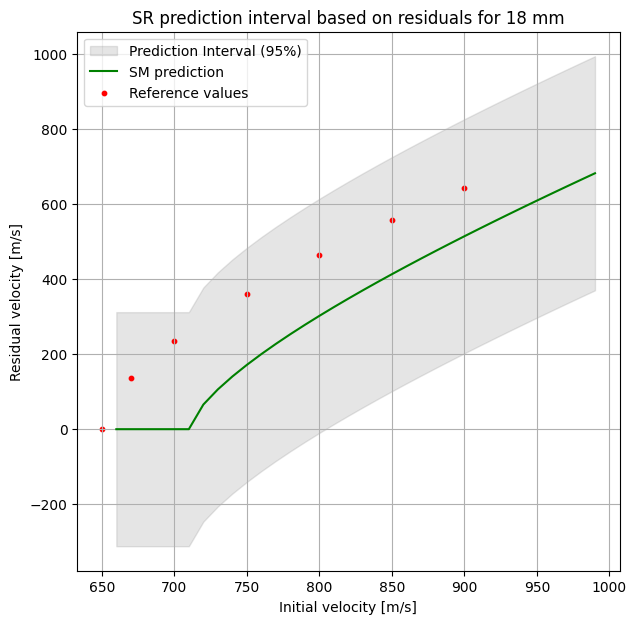

In [110]:
(list_vr_, list_vr_est_, list_vbl_, list_vbl_est_) = calculate_help()

import numpy as np
import matplotlib.pyplot as plt
id_list = 0
id_arr = 0
eps = 0.00001
while list_vr_[id_list][id_arr] < eps and list_vr_est_[id_list][id_arr] < eps and id_arr < list_vr_[id_list].shape[0]:
            id_arr += 1

t = wspolczynniki_list[id_list]

# --- DANE WEJŚCIOWE ---
# vi      - lista wartości X
# vr      - lista wartości rzeczywistych
# vr_exp  - lista błędów (residuów) modelu = vr - y_pred

#vr__ = list_vr[id_list][id_arr:list_vr[id_list].shape[0]]
#vr__est = list_vr_est[id_list][id_arr:list_vr[id_list].shape[0]]
vi = make_sequence(0, 1000, 100)
vi = np.array(vi[id_arr:list_vr_[id_list].shape[0]])
vr = np.array(list_vr_[id_list][id_arr:list_vr_[id_list].shape[0]])
y_pred = np.array(list_vr_est_[id_list][id_arr:list_vr_[id_list].shape[0]])

# --- ODTWORZENIE PREDYKCJI ---
vr_exp = vr - y_pred

# --- OBLICZENIE RMSE ---
rmse = np.sqrt(np.mean(vr_exp**2))

# 95% prediction interval
z = 1.96

from scipy.stats import norm

confidence = 0.95
z = norm.ppf( (1 + confidence) / 2 )

y_lower = y_pred - z * rmse
y_upper = y_pred + z * rmse

# --- WYKRES ---
plt.figure(figsize=(7, 7))
# Prediction Interval
plt.fill_between(vi, y_lower, y_upper, color="gray", alpha=0.2, label="Prediction Interval (95%)")
# Predykcja
plt.plot(vi, y_pred, color="green", label="SM prediction")
# Punkty rzeczywiste
#plt.scatter(vi, vr, label="R-I model values", color="red", s=10)#, alpha=0.6)
##########################################################################

wsp = wspolczynniki[wspolczynniki[:,3] == t]
dd = dane[dane[:,2] == t]
print('t' + str(wsp))
#print(dd)
vbl_ = wsp[0, 0]
aa_ = wsp[0, 1]
pp_ = wsp[0, 2]
#vi_ = make_sequence(0, 1000, 100)
vi_ = dd[:,0]
vir_ = Vr(vi_, aa_, pp_, vbl_)
plt.scatter(vi_, vir_, label="Reference values", color="red", s=10)#, alpha=0.6)
##########################################################################


plt.xlabel('Initial velocity [m/s]')
plt.ylabel('Residual velocity [m/s]')
plt.title("SR prediction interval based on residuals for " + str(round(t,)) + " mm")
plt.legend()
plt.grid(True)
#plt.show()
plt.savefig("./figures/srpi_" + str(round(t,)) + ".eps", dpi=300, format='eps', bbox_inches="tight")


In [88]:
(list_vr_, list_vr_est_, list_vbl_, list_vbl_est_)

([array([  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   

In [68]:
vi

array([ 0., 10., 20., 30., 40., 50., 60., 70., 80.])